# Baseline Model con analisi della razza

Questo notebook addestra modelli di Machine Learning basati sulle feature strutturate del dataset.

Rispetto alla versione precedente, viene aggiunta anche l'analisi della **razza del cane** per verificare se questa informazione modifica o migliora la previsione della velocità di adozione (`AdoptionSpeed`).

L'obiettivo è confrontare:

1. Random Forest senza razza;
2. Random Forest con razza principale e seconda razza.


## 1. Import delle librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

## 2. Caricamento del dataset pulito

Il notebook carica `dogs_clean.csv`, creato nel notebook `01_eda.ipynb`.

Se le colonne `breed1_label` e `breed2_label` non sono ancora presenti, vengono create automaticamente usando il file `breed_labels.csv`.


In [2]:
dogs = pd.read_csv("../data/processed/dogs_clean.csv")

# Se il dataset pulito non contiene ancora i nomi delle razze,
# vengono creati a partire da breed_labels.csv.
if "breed1_label" not in dogs.columns or "breed2_label" not in dogs.columns:
    breed_labels = pd.read_csv("../data/raw/breed_labels.csv")

    breed_map = dict(
        zip(
            breed_labels["BreedID"],
            breed_labels["BreedName"]
        )
    )

    dogs["breed1_label"] = dogs["Breed1"].map(breed_map)
    dogs["breed2_label"] = dogs["Breed2"].map(breed_map)
    dogs["breed2_label"] = dogs["breed2_label"].fillna("None")

print(dogs.shape)

dogs[[
    "Name",
    "Age",
    "breed1_label",
    "breed2_label",
    "AdoptionSpeed"
]].head()

(8132, 32)


,Name,Age,breed1_label,breed2_label,AdoptionSpeed
0,Brisco,1,Mixed Breed,NaN,3
1,Miko,4,Mixed Breed,NaN,2
2,Hunter,1,Mixed Breed,NaN,2
3,Siu Pak & Her 6 Puppies,0,Mixed Breed,NaN,3
4,Bear,2,Mixed Breed,NaN,1


## 3. Feature strutturate senza razza

Questa è la baseline tabellare già utilizzata in precedenza.  
Non include `Breed1` e `Breed2`.


In [3]:
features_without_breed = [
    "Age",
    "Gender",
    "MaturitySize",
    "FurLength",
    "Vaccinated",
    "Dewormed",
    "Sterilized",
    "Health",
    "Quantity",
    "Fee",
    "PhotoAmt",
    "description_len",
    "has_description"
]

X = dogs[features_without_breed]
y = dogs["AdoptionSpeed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(6505, 13)
(1627, 13)


## 4. Random Forest senza razza

In [4]:
rf_without_breed = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    class_weight="balanced",
    random_state=42
)

rf_without_breed.fit(X_train, y_train)

y_pred_without_breed = rf_without_breed.predict(X_test)

accuracy_without_breed = accuracy_score(y_test, y_pred_without_breed)

print("Accuracy senza razza:", accuracy_without_breed)
print(classification_report(y_test, y_pred_without_breed))

Accuracy senza razza: 0.4093423478795329
              precision    recall  f1-score   support

           0       0.18      0.06      0.09        34
           1       0.33      0.28      0.30       287
           2       0.36      0.34      0.35       433
           3       0.43      0.36      0.39       390
           4       0.47      0.62      0.53       483

    accuracy                           0.41      1627
   macro avg       0.35      0.33      0.33      1627
weighted avg       0.40      0.41      0.40      1627



## 5. Feature Importance senza razza

La feature importance permette di capire quali caratteristiche vengono considerate più utili dalla Random Forest.


In [5]:
importance_without_breed = pd.DataFrame({
    "feature": features_without_breed,
    "importance": rf_without_breed.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

importance_without_breed

,feature,importance
11,description_len,0.300232
0,Age,0.159077
10,PhotoAmt,0.153776
9,Fee,0.054715
3,FurLength,0.052511
1,Gender,0.050039
2,MaturitySize,0.049137
8,Quantity,0.043980
6,Sterilized,0.042556
4,Vaccinated,0.041837


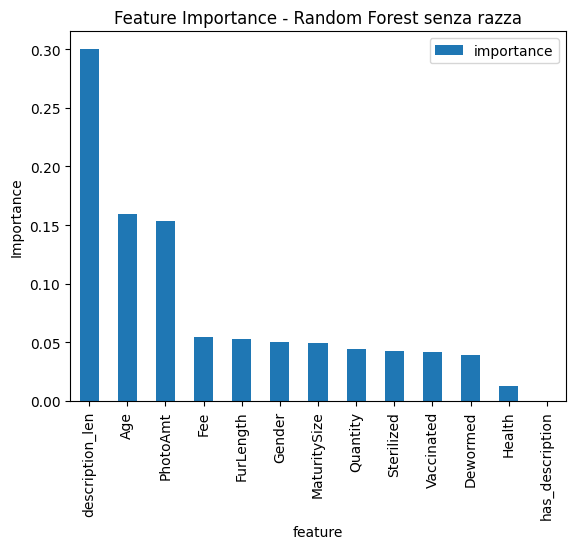

In [6]:
importance_without_breed.plot(
    x="feature",
    y="importance",
    kind="bar"
)

plt.title("Feature Importance - Random Forest senza razza")
plt.ylabel("Importance")
plt.show()

## 6. Analisi esplorativa della razza

Prima di usare la razza nel modello, osserviamo quali sono le razze principali più frequenti e la loro velocità media di adozione.

Attenzione: alcune razze possono avere pochissimi esempi. Per evitare conclusioni poco affidabili, nell'analisi vengono mostrate solo le razze con almeno 30 cani.


In [7]:
breed_counts = dogs["breed1_label"].value_counts()

breed_counts.head(20)

breed1_label
Mixed Breed                  5923
Labrador Retriever            205
Shih Tzu                      189
Poodle                        167
Terrier                       161
Golden Retriever              151
German Shepherd Dog            98
Beagle                         90
Spitz                          89
Rottweiler                     88
Schnauzer                      69
Miniature Pinscher             67
Jack Russell Terrier           64
Doberman Pinscher              62
Cocker Spaniel                 41
Dalmatian                      39
Husky                          37
Chihuahua                      37
Dachshund                      28
Belgian Shepherd Malinois      26
Name: count, dtype: int64

In [8]:
breed_stats = (
    dogs
    .groupby("breed1_label")
    .agg(
        count=("AdoptionSpeed", "size"),
        mean_adoption_speed=("AdoptionSpeed", "mean")
    )
    .reset_index()
)

breed_stats_filtered = breed_stats[breed_stats["count"] >= 30]

breed_stats_filtered.sort_values(
    by="mean_adoption_speed"
).head(20)

,breed1_label,count,mean_adoption_speed
80,Poodle,167,1.976048
96,Shih Tzu,189,2.037037
50,Golden Retriever,151,2.072848
29,Cocker Spaniel,41,2.097561
85,Rottweiler,88,2.102273
88,Schnauzer,69,2.130435
11,Beagle,90,2.200000
25,Chihuahua,37,2.270270
47,German Shepherd Dog,98,2.285714
54,Husky,37,2.297297


In [9]:
breed_stats_filtered.sort_values(
    by="mean_adoption_speed",
    ascending=False
).head(20)

,breed1_label,count,mean_adoption_speed
71,Mixed Breed,5923,2.745230
100,Spitz,89,2.617978
58,Jack Russell Terrier,64,2.578125
104,Terrier,161,2.540373
34,Dalmatian,39,2.461538
35,Doberman Pinscher,62,2.403226
70,Miniature Pinscher,67,2.373134
63,Labrador Retriever,205,2.346341
54,Husky,37,2.297297
47,German Shepherd Dog,98,2.285714


## 7. Modello con razza

Per usare la razza nel modello non è corretto trattare `Breed1` e `Breed2` come numeri ordinati, perché il codice numerico identifica soltanto una categoria.

Per questo motivo vengono usate le colonne testuali:

- `breed1_label`
- `breed2_label`

e viene applicato il **One-Hot Encoding**, che trasforma ogni razza in una variabile binaria.

Il modello riceve quindi:

- feature numeriche/strutturate;
- razza principale;
- seconda razza.


In [10]:
numeric_features = features_without_breed

categorical_features = [
    "breed1_label",
    "breed2_label"
]

X_breed = dogs[numeric_features + categorical_features]
y = dogs["AdoptionSpeed"]

X_train_breed, X_test_breed, y_train_breed, y_test_breed = train_test_split(
    X_breed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("breed", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

rf_with_breed = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    class_weight="balanced",
    random_state=42
)

model_with_breed = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_with_breed)
    ]
)

model_with_breed.fit(X_train_breed, y_train_breed)

y_pred_with_breed = model_with_breed.predict(X_test_breed)

accuracy_with_breed = accuracy_score(y_test_breed, y_pred_with_breed)

print("Accuracy con razza:", accuracy_with_breed)
print(classification_report(y_test_breed, y_pred_with_breed))

Accuracy con razza: 0.44130301167793484
              precision    recall  f1-score   support

           0       0.14      0.03      0.05        34
           1       0.38      0.41      0.39       287
           2       0.37      0.38      0.38       433
           3       0.43      0.34      0.38       390
           4       0.54      0.63      0.58       483

    accuracy                           0.44      1627
   macro avg       0.37      0.36      0.36      1627
weighted avg       0.43      0.44      0.43      1627



## 8. Confronto tra modelli

In questa sezione viene confrontata la Random Forest senza razza con la Random Forest che include anche `breed1_label` e `breed2_label`.


In [11]:
results = pd.DataFrame({
    "Model": [
        "Random Forest senza razza",
        "Random Forest con razza"
    ],
    "Accuracy": [
        accuracy_without_breed,
        accuracy_with_breed
    ]
})

results

,Model,Accuracy
0,Random Forest senza razza,0.409342
1,Random Forest con razza,0.441303


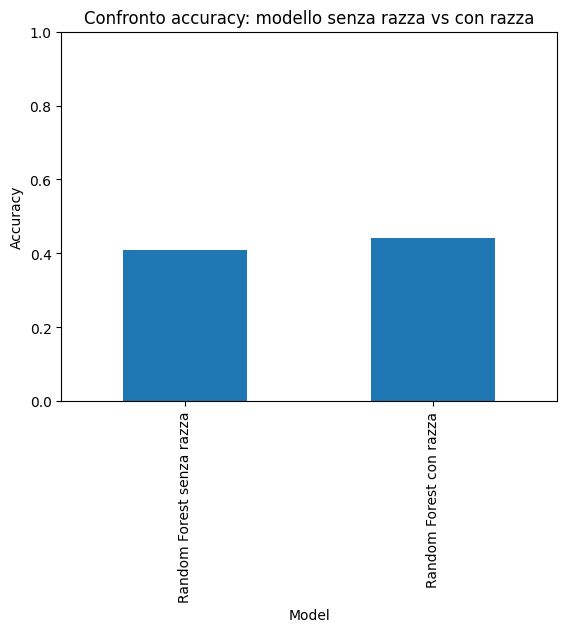

In [12]:
results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title("Confronto accuracy: modello senza razza vs con razza")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## 9. Feature Importance del modello con razza

Questa sezione mostra le feature più importanti del modello che include anche le razze.

Le razze sono state trasformate tramite One-Hot Encoding, quindi appaiono come feature del tipo:

- `breed__breed1_label_Labrador Retriever`
- `breed__breed2_label_Golden Retriever`


In [13]:
# Recupero nomi delle feature dopo il preprocessing
feature_names = model_with_breed.named_steps["preprocessor"].get_feature_names_out()

feature_importances = model_with_breed.named_steps["classifier"].feature_importances_

importance_with_breed = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(
    by="importance",
    ascending=False
)

importance_with_breed.head(30)

,feature,importance
198,num__description_len,0.166748
187,num__Age,0.126055
197,num__PhotoAmt,0.115777
193,num__Sterilized,0.048696
188,num__Gender,0.044185
190,num__FurLength,0.044043
196,num__Fee,0.043731
189,num__MaturitySize,0.041961
195,num__Quantity,0.038861
191,num__Vaccinated,0.037657


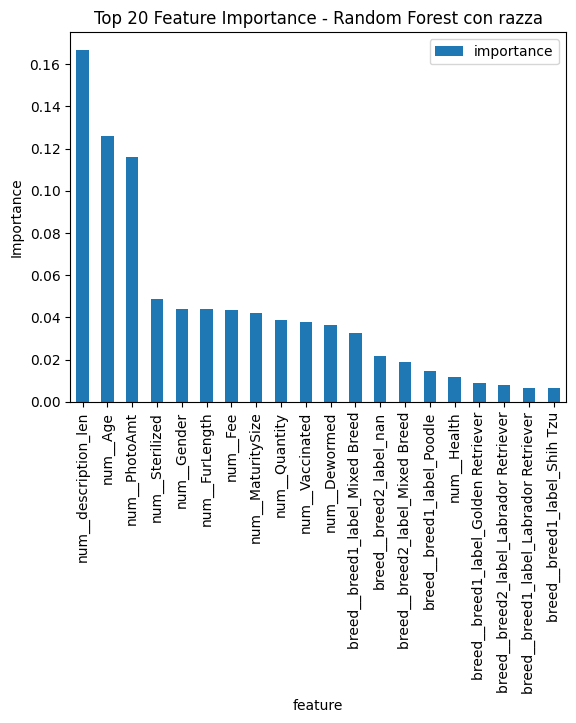

In [14]:
importance_with_breed.head(20).plot(
    x="feature",
    y="importance",
    kind="bar"
)

plt.title("Top 20 Feature Importance - Random Forest con razza")
plt.ylabel("Importance")
plt.show()

## 10. Conclusioni

Questo notebook permette di verificare se la razza del cane contribuisce alla previsione della velocità di adozione.

Se il modello con razza ottiene un'accuracy maggiore rispetto al modello senza razza, significa che `Breed1` e `Breed2` aggiungono informazione utile.

Se invece l'accuracy resta simile o diminuisce, la razza potrebbe essere meno utile per la previsione predittiva generale, ma resta comunque importante per il sistema di matching cane–famiglia, perché molte famiglie possono esprimere preferenze esplicite sulle razze.

In ogni caso, la razza viene considerata una variabile utile nella parte di raccomandazione personalizzata.
